# Checking PICO

Compares our own calculated thermal forcing (TF) against the TF time series
Ronja/PIK supplied directly (`reviewing/TF_PICO_expt_0{2,3,4,5}.nc`), for
PIK_PISM, across all four climate forcing experiments (expAE02-expAE05) and
all six regions (AIS, Amundsen, Ross, Filchner-Ronne, Aurora, Wilkes).

Four outputs:
1. A per-experiment, per-region summary table: correlation between our TF and
   PICO's TF, and the melt sensitivity (MS) refit from each TF source, using
   PIK_PISM's own established fitting method (`df_maxbmb`, i.e. fit until the
   year of maximum BMB, from `time_maximum_BMB.csv`), plus the relative error
   of MS_PICO against MS_ours (%). Saved as a CSV and an SI-ready LaTeX table.
2. Diagnostic figures (TF time-series comparison, and BMB-vs-TF scatter with
   fitted lines), one panel per region, both TF sources plotted together,
   generated separately for each of the four experiments.
3. A single combined SI example figure for expAE02: TF comparison (top row)
   and BMB-vs-TF scatter (bottom row) for all six regions, in one figure.
4. A summary figure: for each region, the MS derived across the four
   experiments (mean, with an error bar spanning min-max), for our TF and for
   PICO's TF side by side.

Requires the external drive to be mounted (our own TF is not part of the
synced `ComputedScalars` copy used elsewhere in this analysis).

In [40]:
import os
import numpy as np
import pandas as pd
import xarray as xr
from scipy.stats import linregress, pearsonr
import matplotlib.pyplot as plt

MODEL = 'PIK_PISM'
EXPS = ['expAE02', 'expAE03', 'expAE04', 'expAE05']

mnt_pth = '/Volumes/CrucialX8/computing/data/antarctica/'
pth_imip6hack = mnt_pth + 'ismip6_hackathon/ComputedScalars/'   # thermal forcing lives here
pth_helene = mnt_pth + 'ismip6_hackathon/ComputedScalarsHelene/'  # BMB (shelfmelt) and area (iareafl) live here

renamer = {}
renamer['DOE_MALI_4km'] = 'DOE_MALI_1'
renamer['DOE_MALI_8km_Ant95'] = 'DOE_MALI_2'
renamer['DOE_MALI_8km_AntMean'] = 'DOE_MALI_3'

dic_area_of_interest = {}
dic_area_of_interest['AIS'] = ['']
dic_area_of_interest['Amundsen'] = ['_sector_4']
dic_area_of_interest['FilchnerRonne'] = ['_sector_5', '_sector_11']
dic_area_of_interest['Ross'] = ['_sector_2', '_sector_6']
dic_area_of_interest['Aurora'] = ['_sector_8']
dic_area_of_interest['Wilkes'] = ['_sector_7']

# region name -> variable name in TF_PICO_expt_0X.nc
PICO_VAR = {
    'AIS': 'thermal_forcing_ais', 'Amundsen': 'thermal_forcing_ase',
    'Ross': 'thermal_forcing_ross', 'FilchnerRonne': 'thermal_forcing_fris',
    'Aurora': 'thermal_forcing_aurora', 'Wilkes': 'thermal_forcing_wilkes',
}
REGIONS = list(PICO_VAR.keys())

# time_maximum_BMB.csv column holding the cutoff year for each region
TMAX_COL = {'Aurora': 'sector_8', 'Wilkes': 'sector_7'}

# expAE0X -> reviewing/TF_PICO_expt_0X.nc
PICO_FILE = {exp: f'./../reviewing/TF_PICO_expt_{exp[-2:]}.nc' for exp in EXPS}

os.makedirs('figs/checking_pico', exist_ok=True)

In [41]:
df_time = pd.read_csv('tables/time_maximum_BMB.csv')
df_best = pd.read_csv('tables/best_ms_method_per_model.csv')
row_best = df_best[df_best.Model == MODEL].iloc[0]
print('fitting method for', MODEL, ':', row_best['method'])

fitting method for PIK_PISM : df_maxbmb


In [42]:
def compute_region(exp, region):
    '''Load our TF/BMB/area and PICO's TF for one (experiment, region), refit
    MS against both TF sources using the df_maxbmb cutoff, and return everything
    needed both for the summary table and for the diagnostic plots.'''
    nmname = renamer[MODEL] if MODEL in renamer else MODEL

    pth_tf = f'{pth_imip6hack}/{exp}/thermalforcing/computed_thermalforcing_AIS_{nmname}_{exp}.nc'
    pth_bmb = f'{pth_helene}/{exp}/shelfmelt/computed_shelfmelt_AIS_{nmname}_{exp}.nc'
    pth_area = f'{pth_helene}/{exp}/iareafl/computed_iareafl_AIS_{nmname}_{exp}.nc'

    d_tf = xr.open_dataset(pth_tf, decode_times=False)
    d_bmb = xr.open_dataset(pth_bmb, decode_times=False)
    d_area = xr.open_dataset(pth_area, decode_times=False)
    d_pico = xr.open_dataset(PICO_FILE[exp], decode_times=False)

    y2sec = -365.25 * 24 * 3600
    factor = y2sec / 10**3  # kg/s -> t/yr, matching the MS-fitting notebook's own convention

    n = min(d_tf.time.size, d_bmb.time.size, d_area.time.size, d_pico.time.size)
    time = d_bmb.time.values[:n]

    sectors = dic_area_of_interest[region]
    if sectors == ['']:
        y = d_bmb['shelfmelt'].values[:n] * factor
        area = d_area['iareafl'].values[:n]
        tf_ours = d_tf['thermalforcing'].values[:n]
    else:
        the_ys = np.zeros((len(sectors), n))
        the_areas = np.zeros((len(sectors), n))
        the_tfs = np.zeros((len(sectors), n))
        for k, nm in enumerate(sectors):
            the_ys[k, :] = d_bmb[f'shelfmelt{nm}'].values[:n] * factor
            the_areas[k, :] = d_area[f'iareafl{nm}'].values[:n]
            the_tfs[k, :] = d_tf[f'thermalforcing{nm}'].values[:n] * d_area[f'iareafl{nm}'].values[:n]
        y = np.sum(the_ys, axis=0)
        area = np.sum(the_areas, axis=0)
        tf_ours = np.sum(the_tfs, axis=0) / area

    bmb_avg = y / area
    tf_pico = d_pico[PICO_VAR[region]].values[:n]

    # TF-TF correlation
    valid = ~np.isnan(tf_ours) & ~np.isnan(tf_pico)
    r_tf, p_tf = pearsonr(tf_ours[valid], tf_pico[valid])

    # MS refit cutoff (df_maxbmb: fit until year of max BMB for this model/experiment)
    row_time = df_time[(df_time.Model == MODEL) & (df_time.Experiment == exp)].iloc[0]
    t_max_col = TMAX_COL.get(region, region)
    t_max = min(row_time[t_max_col], 2298)
    tmin = np.where(time >= t_max)[0][0] if np.any(time >= t_max) else n
    used = (np.arange(n) < tmin) & ~np.isnan(bmb_avg)

    used_ours = used & ~np.isnan(tf_ours)
    used_pico = used & ~np.isnan(tf_pico)
    fit_ours = linregress(tf_ours[used_ours], bmb_avg[used_ours])
    fit_pico = linregress(tf_pico[used_pico], bmb_avg[used_pico])

    d_tf.close(); d_bmb.close(); d_area.close(); d_pico.close()

    return dict(
        time=time, tf_ours=tf_ours, tf_pico=tf_pico, bmb_avg=bmb_avg,
        valid=valid, used_ours=used_ours, used_pico=used_pico,
        r_tf=r_tf, p_tf=p_tf, n_tf=int(valid.sum()),
        fit_ours=fit_ours, fit_pico=fit_pico,
    )


results = {}
summary_rows = []
for exp in EXPS:
    results[exp] = {}
    for region in REGIONS:
        res = compute_region(exp, region)
        results[exp][region] = res
        ms_ours = res['fit_ours'].slope
        ms_pico = res['fit_pico'].slope
        ms_relerr_pct = (ms_ours - ms_pico) / ms_ours * 100
        summary_rows.append(dict(
            Experiment=exp, Region=region,
            pearson_r_TF=res['r_tf'], p_TF=res['p_tf'], n_TF=res['n_tf'],
            MS_ours=ms_ours, r2_ours=res['fit_ours'].rvalue**2, p_ours=res['fit_ours'].pvalue,
            MS_PICO=ms_pico, r2_PICO=res['fit_pico'].rvalue**2, p_PICO=res['fit_pico'].pvalue,
            MS_relerr_pct=ms_relerr_pct,
        ))

df_summary = pd.DataFrame(summary_rows)
df_summary.to_csv('./../reviewing/tables/PIK_PISM_TF_MS_PICO_summary_allexp.csv', index=False)
print(df_summary.to_string(index=False))

Experiment        Region  pearson_r_TF          p_TF  n_TF   MS_ours  r2_ours        p_ours   MS_PICO  r2_PICO        p_PICO  MS_relerr_pct
   expAE02           AIS      0.954473 1.050316e-150   285  2.541301 0.975640  1.815834e-99  3.008855 0.982880 7.513885e-108     -18.398195
   expAE02      Amundsen      0.934339 7.914249e-129   285  4.285472 0.682367  3.346393e-61  5.019369 0.548383  8.576896e-43     -17.125224
   expAE02          Ross      0.924193 2.570678e-120   285  1.331882 0.784504  3.301714e-57  1.720336 0.928739  1.474643e-96     -29.165753
   expAE02 FilchnerRonne      0.872487  5.217526e-90   285  2.850181 0.873961  4.601863e-58  3.139504 0.946354  1.252128e-80     -10.151055
   expAE02        Aurora      0.937852 4.257198e-132   285 17.486518 0.942490 3.513853e-155 12.142508 0.925021 2.189182e-140      30.560746
   expAE02        Wilkes      0.947421 4.497185e-142   285 19.324757 0.937250 2.559886e-155 12.660959 0.942165 3.237904e-159      34.483216
   expAE03          

In [43]:
def fmt_p(p):
    if p < 1e-3:
        exp = int(np.floor(np.log10(p)))
        mant = p / 10**exp
        return f'${mant:.1f}\\times10^{{{exp}}}$'
    return f'{p:.3f}'

lines = []
lines.append('\\begin{table}[h]')
lines.append('\\centering')
lines.append('\\caption{Comparison of our calculated thermal forcing (TF) against PIK/PICO-supplied TF for PIK\\_PISM, across all four climate forcing experiments and six regions. Pearson $r$ (TF--TF) is the correlation between the two TF time series; MS$_\\mathrm{ours}$ and MS$_\\mathrm{PICO}$ are the melt sensitivities refit against each TF source using the df\\_maxbmb cutoff; the relative error is $(\\mathrm{MS}_\\mathrm{ours}-\\mathrm{MS}_\\mathrm{PICO})/\\mathrm{MS}_\\mathrm{ours}\\times100$.}')
lines.append('\\label{table_SI_PICO_TF_MS_summary}')
lines.append('\\begin{tabular}{llcccccc}')
lines.append('\\hline')
lines.append('Experiment & Region & $r$ (TF--TF) & MS$_\\mathrm{ours}$ & $r^2_\\mathrm{ours}$ & MS$_\\mathrm{PICO}$ & $r^2_\\mathrm{PICO}$ & rel.\\ err.\\ (\\%) \\\\')
lines.append('\\hline')
for _, row in df_summary.iterrows():
    line = (f'{row.Experiment} & {row.Region} & {row.pearson_r_TF:.2f} & '
            f'{row.MS_ours:.2f} & {row.r2_ours:.2f} & '
            f'{row.MS_PICO:.2f} & {row.r2_PICO:.2f} & '
            f'{row.MS_relerr_pct:.1f} \\\\')
    lines.append(line)
lines.append('\\hline')
lines.append('\\end{tabular}')
lines.append('\\end{table}')

with open('./../reviewing/tables/Table_SI_PICO_TF_MS_summary.tex', 'w') as f:
    f.write('\n'.join(lines))
print('wrote reviewing/tables/Table_SI_PICO_TF_MS_summary.tex')

wrote reviewing/tables/Table_SI_PICO_TF_MS_summary.tex


## 1. Diagnostic plots per experiment (both TF sources in one panel per region)

For each experiment: TF time-series comparison, then BMB-vs-TF scatter with
fitted lines (using the same `df_maxbmb` cutoff and refit stored in `results`
above).

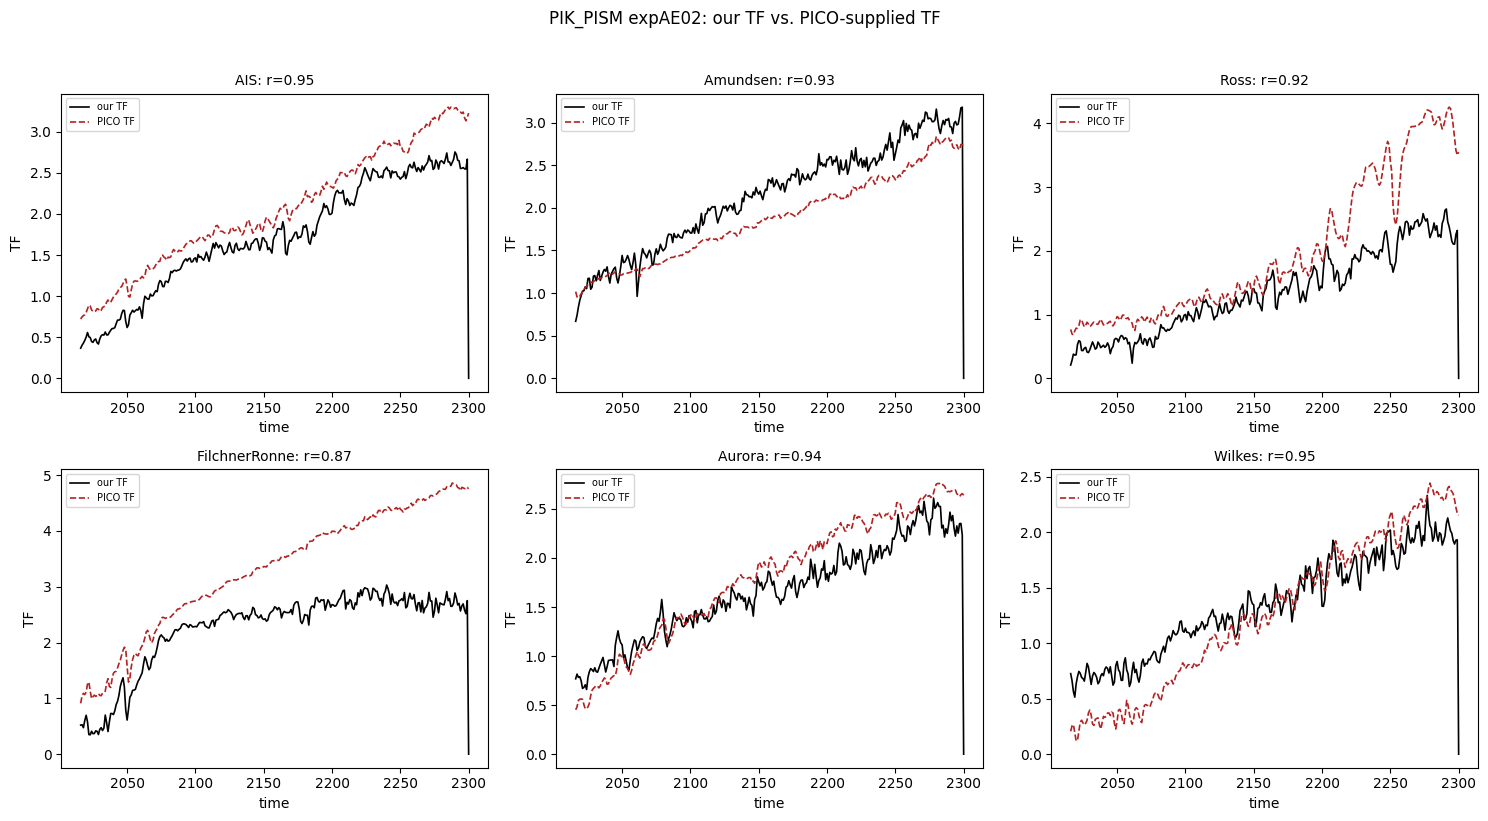

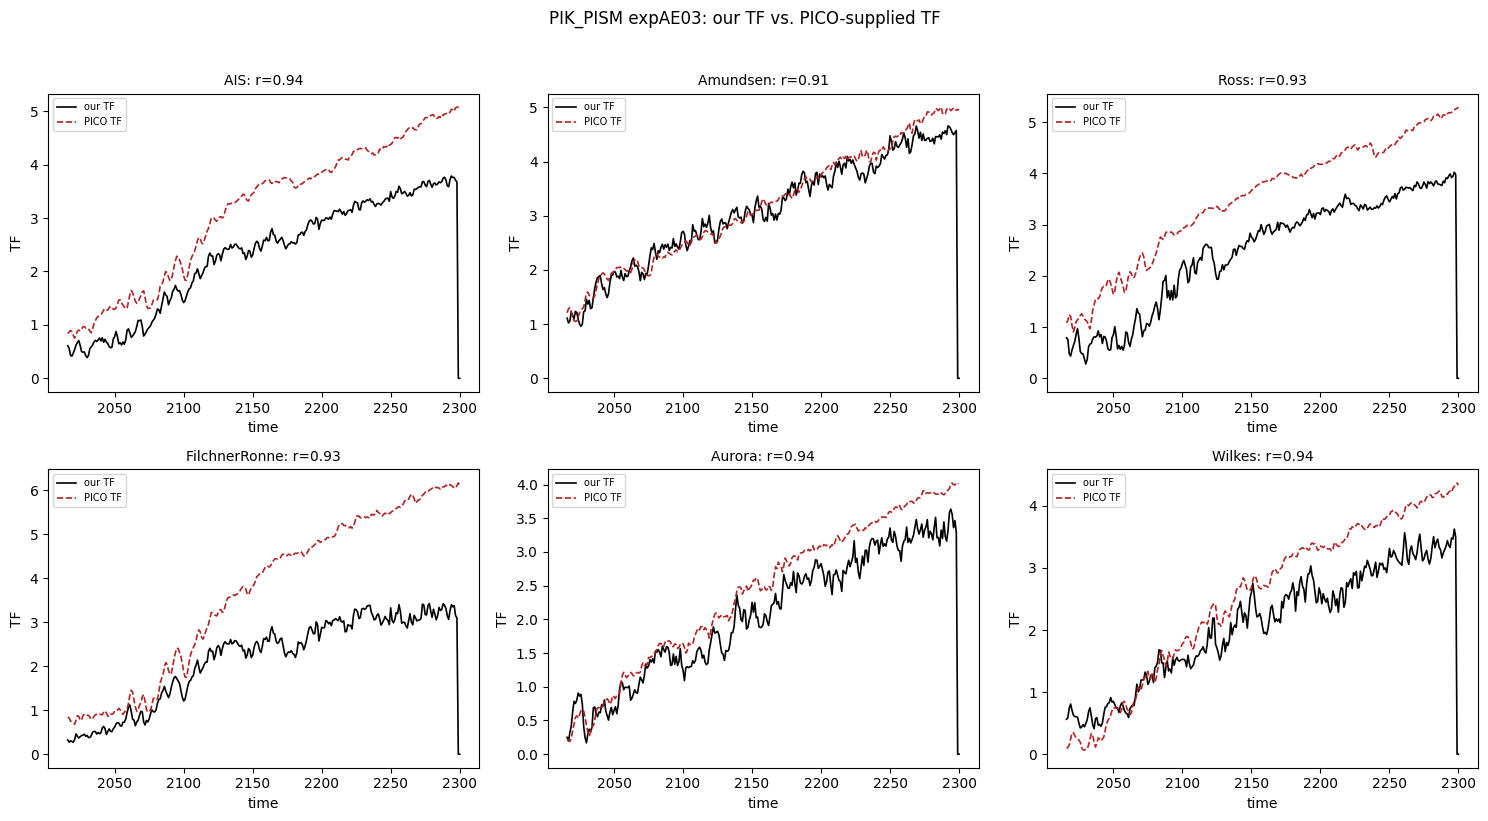

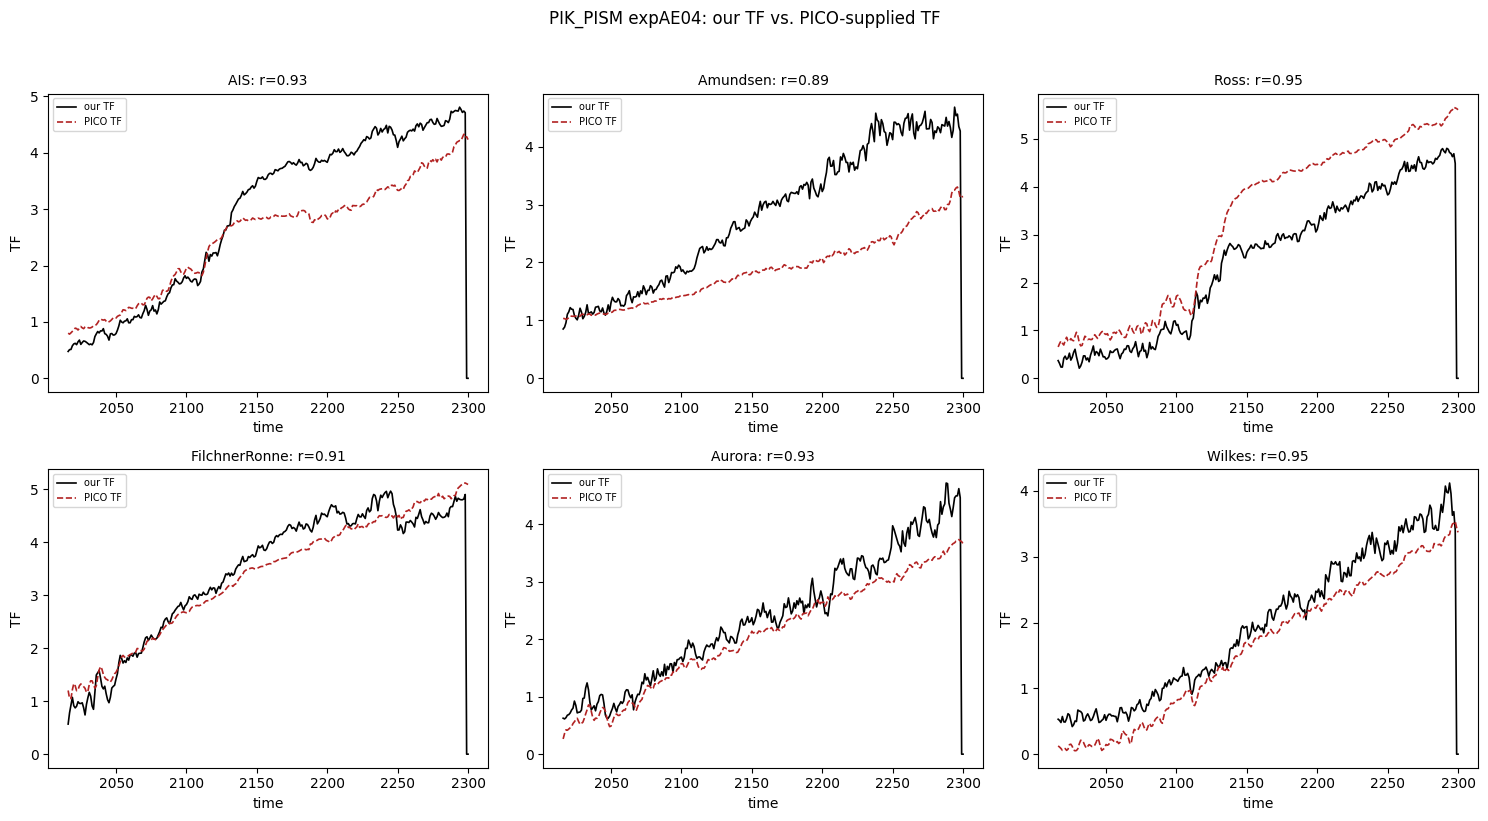

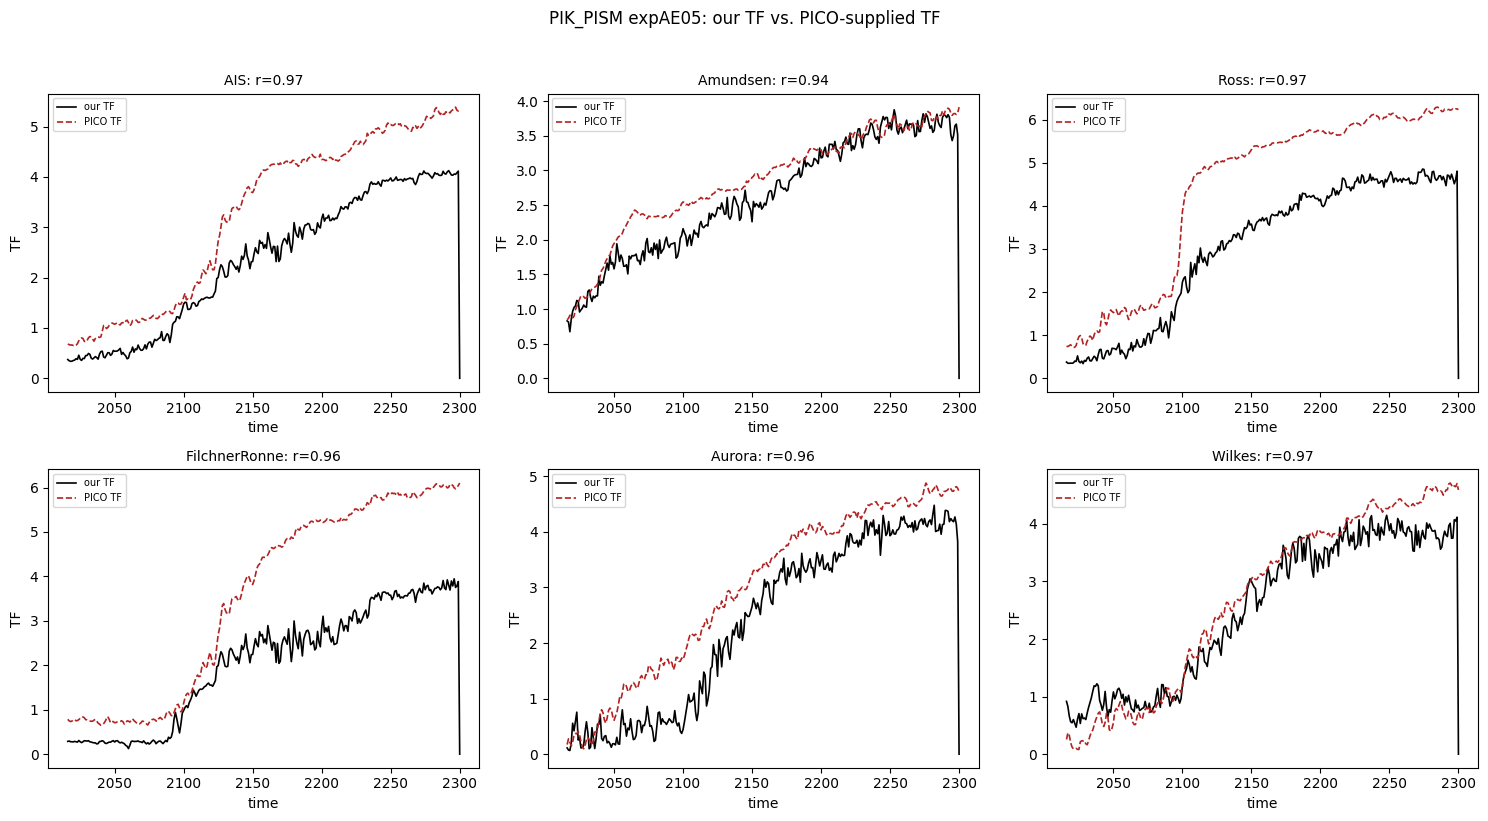

In [44]:
for exp in EXPS:
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    for ax, region in zip(axes.flat, REGIONS):
        res = results[exp][region]
        time, tf_ours, tf_pico, valid = res['time'], res['tf_ours'], res['tf_pico'], res['valid']
        ax.plot(time[valid], tf_ours[valid], color='black', lw=1.2, label='our TF')
        ax.plot(time[valid], tf_pico[valid], color='firebrick', lw=1.2, ls='--', label='PICO TF')
        ax.set_title(f'{region}: r={res["r_tf"]:.2f}', fontsize=10)
        ax.set_xlabel('time')
        ax.set_ylabel('TF')
        ax.legend(fontsize=7)
    fig.suptitle(f'{MODEL} {exp}: our TF vs. PICO-supplied TF', y=1.02)
    plt.tight_layout()
    fig.savefig(f'figs/checking_pico/PIK_PISM_TF_ours_vs_PICO_timeseries_{exp}.pdf', bbox_inches='tight')
    fig.savefig(f'./../reviewing/figures/PIK_PISM_TF_ours_vs_PICO_timeseries_{exp}.pdf', bbox_inches='tight')
    plt.show()

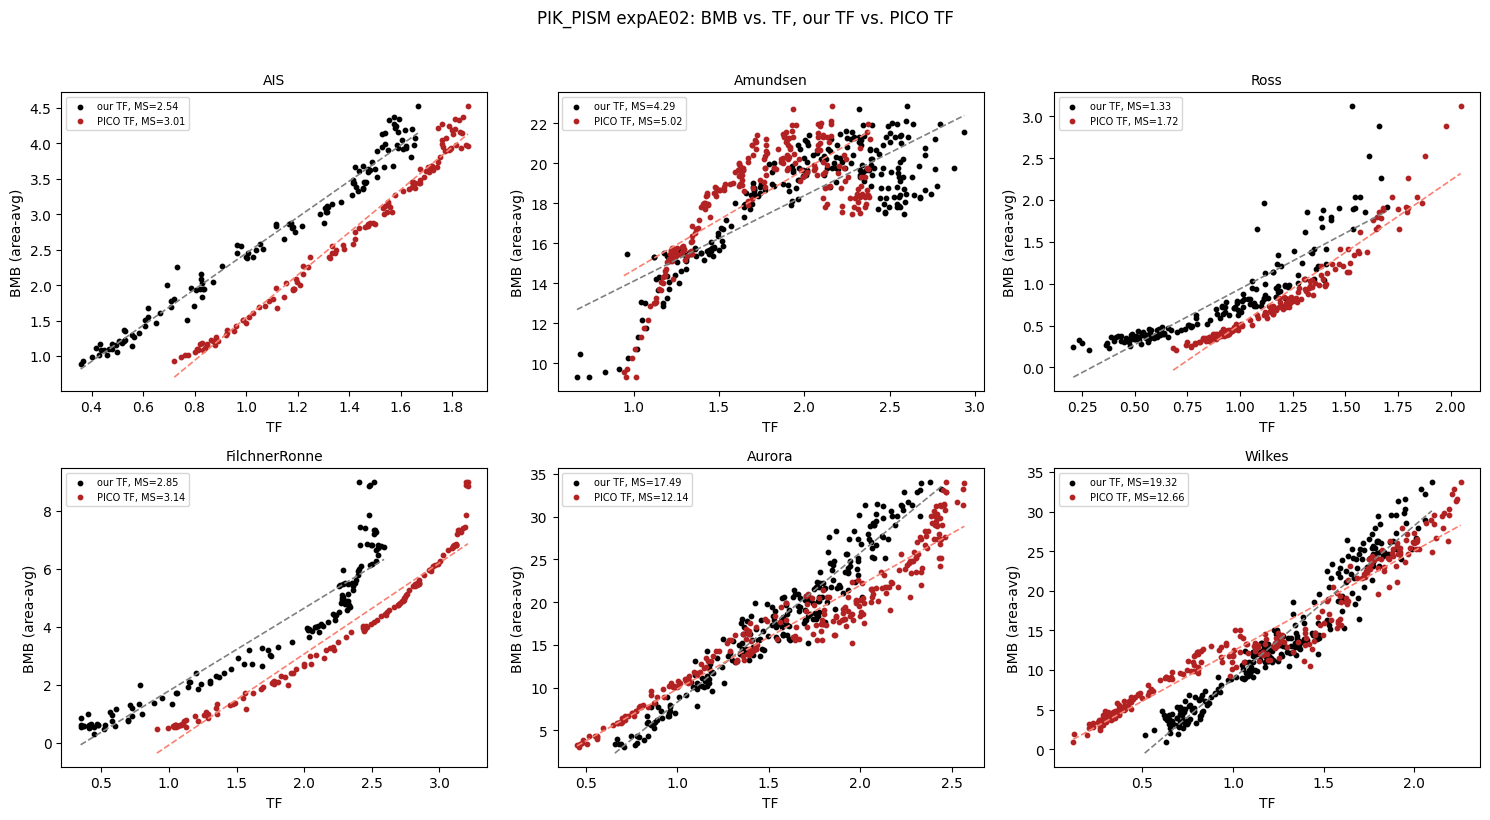

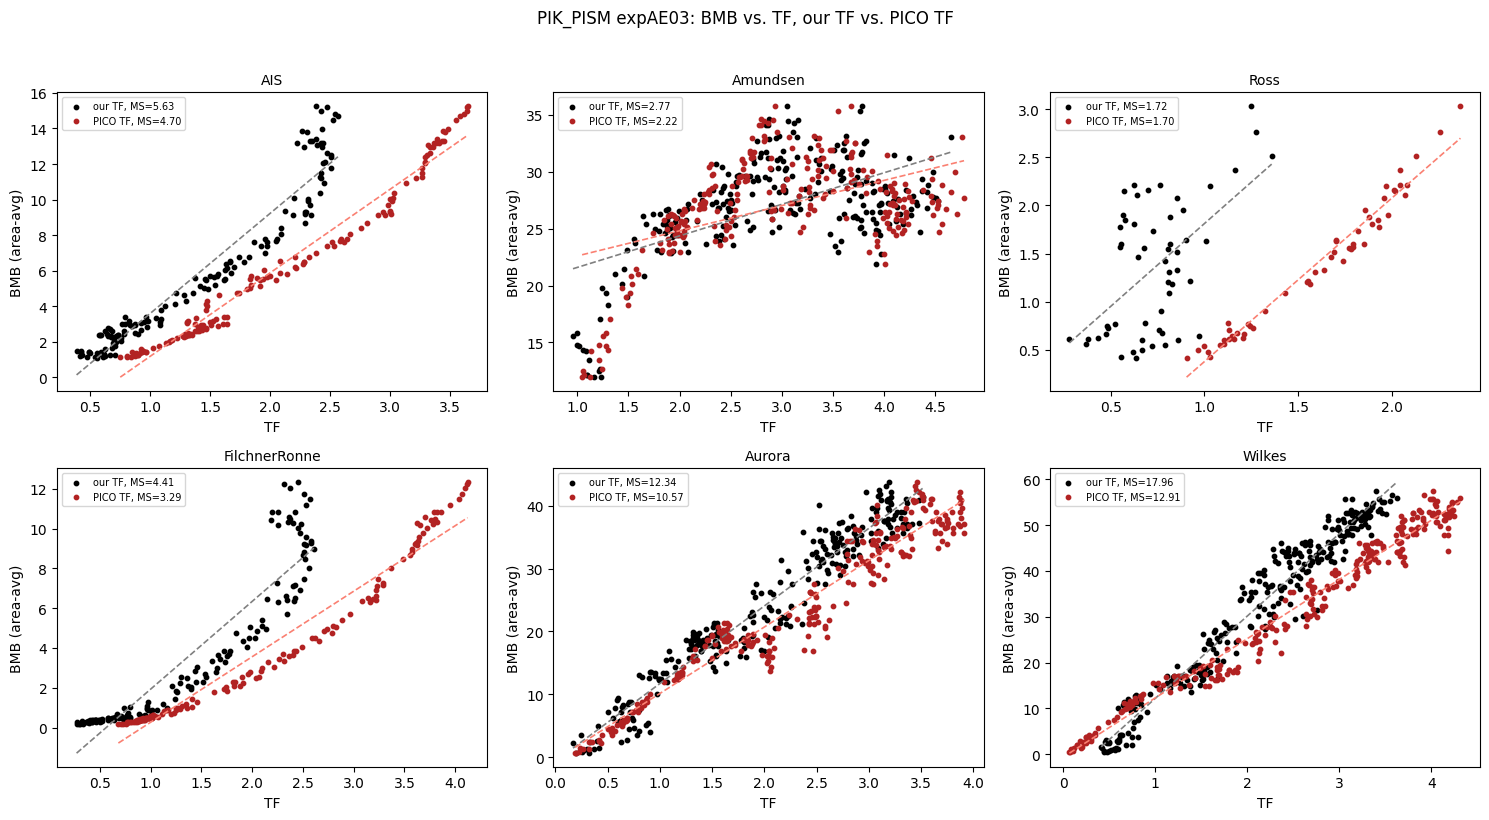

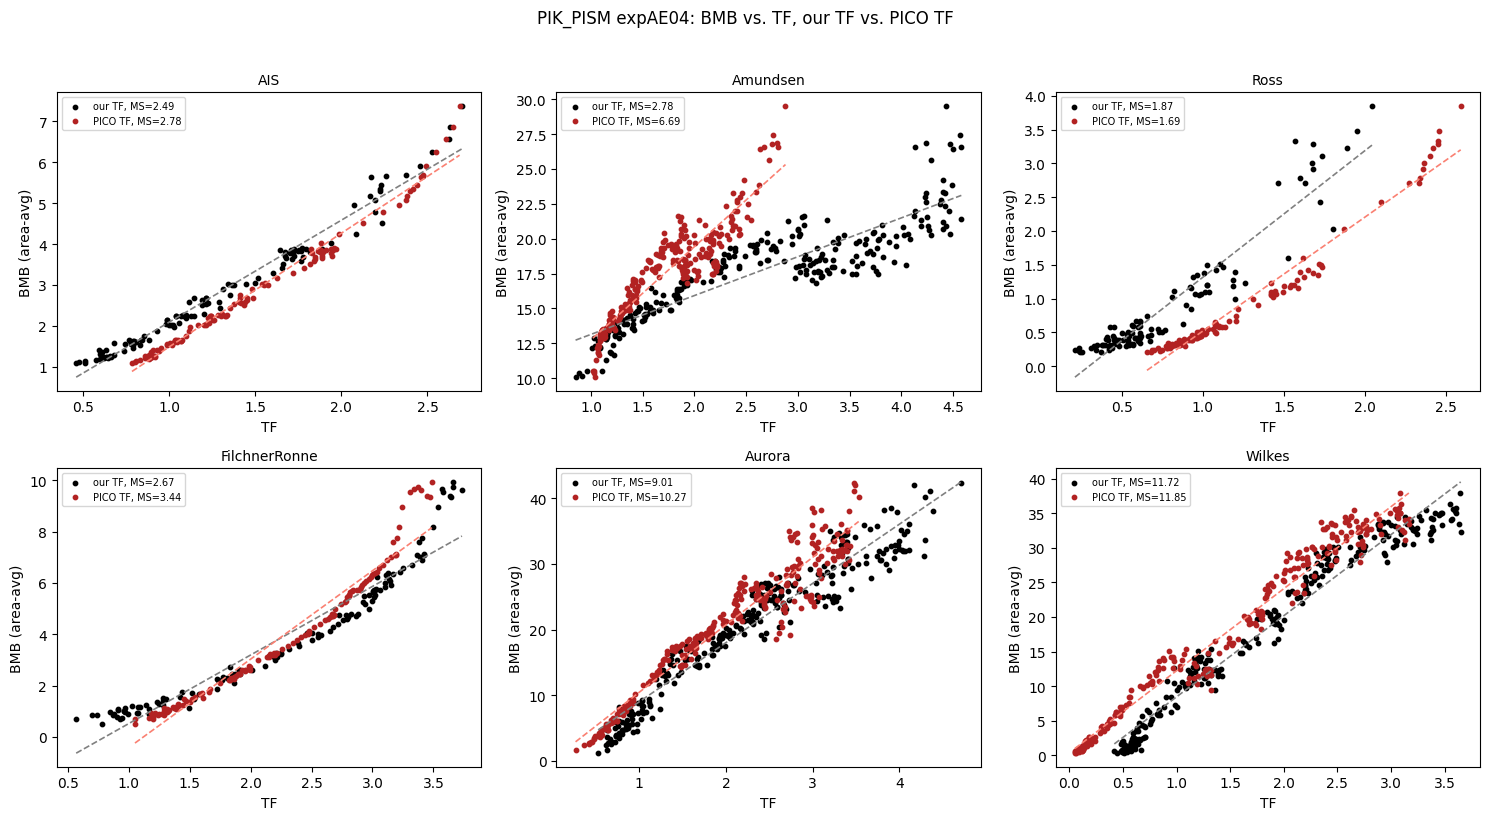

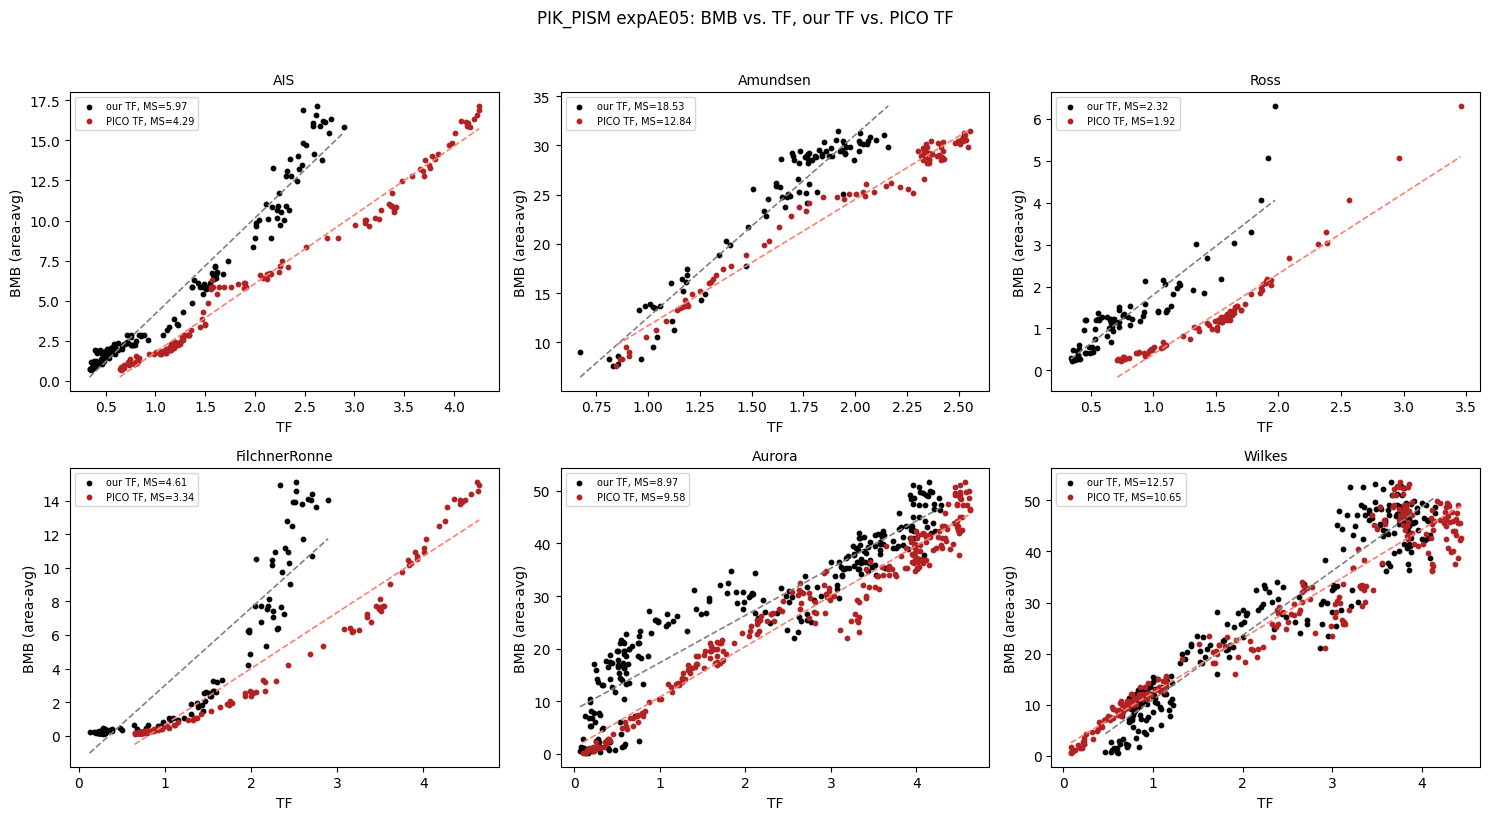

In [45]:
for exp in EXPS:
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    for ax, region in zip(axes.flat, REGIONS):
        res = results[exp][region]
        tf_ours, tf_pico, bmb_avg = res['tf_ours'], res['tf_pico'], res['bmb_avg']
        used_ours, used_pico = res['used_ours'], res['used_pico']
        fit_ours, fit_pico = res['fit_ours'], res['fit_pico']

        ax.scatter(tf_ours[used_ours], bmb_avg[used_ours], s=10, color='black',
                   label=f'our TF, MS={fit_ours.slope:.2f}')
        ax.scatter(tf_pico[used_pico], bmb_avg[used_pico], s=10, color='firebrick',
                   label=f'PICO TF, MS={fit_pico.slope:.2f}')
        xline_ours = np.linspace(tf_ours[used_ours].min(), tf_ours[used_ours].max(), 50)
        xline_pico = np.linspace(tf_pico[used_pico].min(), tf_pico[used_pico].max(), 50)
        ax.plot(xline_ours, fit_ours.slope * xline_ours + fit_ours.intercept, '--', color='gray', lw=1.2)
        ax.plot(xline_pico, fit_pico.slope * xline_pico + fit_pico.intercept, '--', color='salmon', lw=1.2)
        ax.set_title(region, fontsize=10)
        ax.set_xlabel('TF')
        ax.set_ylabel('BMB (area-avg)')
        ax.legend(fontsize=7)
    fig.suptitle(f'{MODEL} {exp}: BMB vs. TF, our TF vs. PICO TF', y=1.02)
    plt.tight_layout()
    fig.savefig(f'figs/checking_pico/PIK_PISM_MS_ours_vs_PICO_{exp}.pdf', bbox_inches='tight')
    fig.savefig(f'./../reviewing/figures/PIK_PISM_MS_ours_vs_PICO_{exp}.pdf', bbox_inches='tight')
    plt.show()

## SI example figure (expAE02): TF comparison and MS scatter, all regions, one figure

A single combined figure for the SI: top row is the TF time-series comparison
per region, bottom row is the BMB-vs-TF scatter with fitted lines per region,
both for expAE02 only.

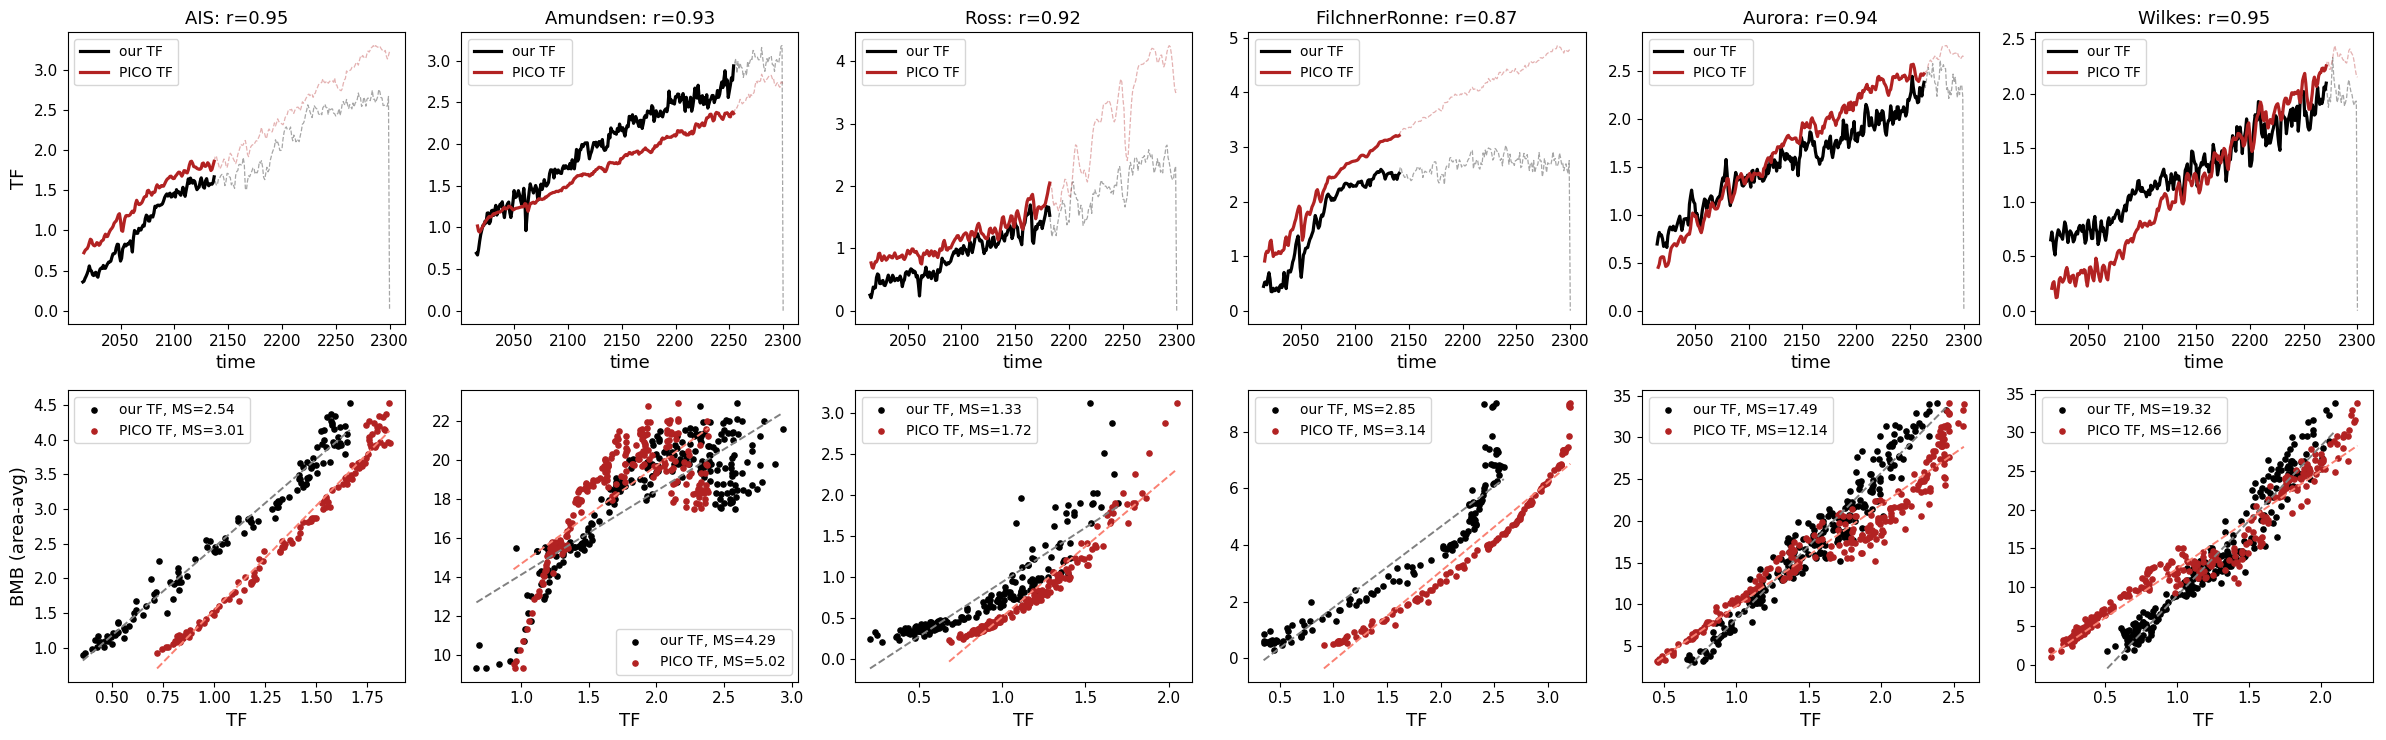

In [48]:
# Note on the TF-TF correlation (r, shown in each top-row title): it is computed
# over the entire available TF time series (all timesteps where both our TF and
# PICO's TF are non-NaN), not restricted to the df_maxbmb window used for the MS
# fit. In the top row below, the portion of each TF curve that actually enters
# the MS fit (i.e. up to the df_maxbmb cutoff) is drawn solid and thick; the
# remainder is drawn dashed and light.

exp = 'expAE02'
fig, axes = plt.subplots(2, len(REGIONS), figsize=(4 * len(REGIONS), 7.5))

LABEL_FS = 13
TITLE_FS = 13
LEGEND_FS = 10
TICK_FS = 11

for col, region in enumerate(REGIONS):
    res = results[exp][region]

    ax = axes[0, col]
    time, tf_ours, tf_pico, valid = res['time'], res['tf_ours'], res['tf_pico'], res['valid']
    used_ours, used_pico = res['used_ours'], res['used_pico']

    # full series: light, dashed (excluded from the MS fit)
    ax.plot(time[valid], tf_ours[valid], color='black', lw=0.9, ls='--', alpha=0.35)
    ax.plot(time[valid], tf_pico[valid], color='firebrick', lw=0.9, ls='--', alpha=0.35)
    # portion entering the MS fit: solid, thick
    ax.plot(time[used_ours], tf_ours[used_ours], color='black', lw=2.3, label='our TF')
    ax.plot(time[used_pico], tf_pico[used_pico], color='firebrick', lw=2.3, label='PICO TF')

    ax.set_title(f'{region}: r={res["r_tf"]:.2f}', fontsize=TITLE_FS)
    ax.set_xlabel('time', fontsize=LABEL_FS)
    if col == 0:
        ax.set_ylabel('TF', fontsize=LABEL_FS)
    ax.tick_params(labelsize=TICK_FS)
    ax.legend(fontsize=LEGEND_FS)

    ax = axes[1, col]
    tf_ours, tf_pico, bmb_avg = res['tf_ours'], res['tf_pico'], res['bmb_avg']
    fit_ours, fit_pico = res['fit_ours'], res['fit_pico']
    ax.scatter(tf_ours[used_ours], bmb_avg[used_ours], s=14, color='black',
               label=f'our TF, MS={fit_ours.slope:.2f}')
    ax.scatter(tf_pico[used_pico], bmb_avg[used_pico], s=14, color='firebrick',
               label=f'PICO TF, MS={fit_pico.slope:.2f}')
    xline_ours = np.linspace(tf_ours[used_ours].min(), tf_ours[used_ours].max(), 50)
    xline_pico = np.linspace(tf_pico[used_pico].min(), tf_pico[used_pico].max(), 50)
    ax.plot(xline_ours, fit_ours.slope * xline_ours + fit_ours.intercept, '--', color='gray', lw=1.4)
    ax.plot(xline_pico, fit_pico.slope * xline_pico + fit_pico.intercept, '--', color='salmon', lw=1.4)
    ax.set_xlabel('TF', fontsize=LABEL_FS)
    if col == 0:
        ax.set_ylabel('BMB (area-avg)', fontsize=LABEL_FS)
    ax.tick_params(labelsize=TICK_FS)
    ax.legend(fontsize=LEGEND_FS)

# fig.suptitle(f'{MODEL} {exp}: TF comparison (top) and BMB-vs-TF MS refit (bottom), our TF vs. PICO TF', y=1.03, fontsize=15)
# fig.text(0.5, 0.995, 'top row: solid/thick = years entering the MS fit (df_maxbmb window); dashed/light = excluded',
#           ha='center', va='top', fontsize=10, style='italic')
plt.tight_layout()
fig.savefig(f'figs/checking_pico/PIK_PISM_TF_and_MS_SI_example_{exp}.pdf', bbox_inches='tight')
fig.savefig(f'./../reviewing/figures/PIK_PISM_TF_and_MS_SI_example_{exp}.pdf', bbox_inches='tight')
plt.show()

## 2. Summary: MS per region, mean across the four experiments with min-max error bars

For each region, the mean MS across expAE02-expAE05 (marker), with an error
bar spanning the min-max range across the four experiments, shown for both
our TF-derived MS and PICO TF-derived MS.

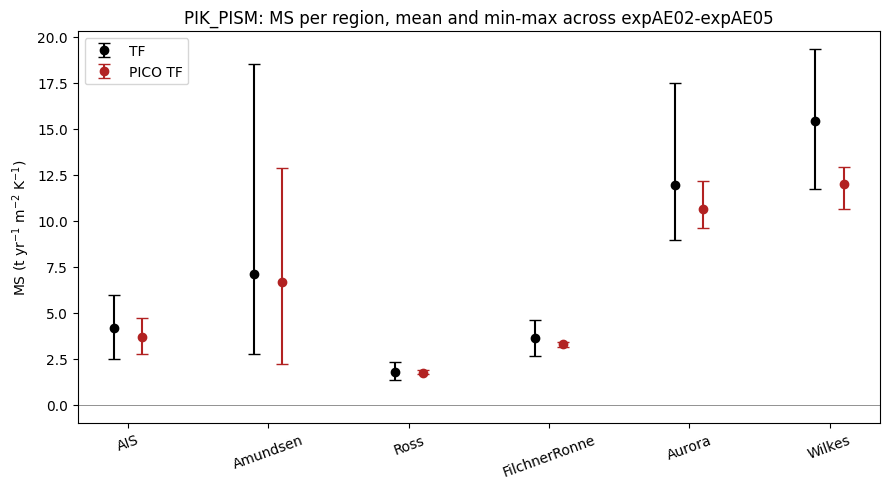

               MS_ours_mean  MS_ours_min  MS_ours_max  MS_PICO_mean  \
Region                                                                
AIS                4.159246     2.491689     5.972415      3.693001   
Amundsen           7.094027     2.774720    18.531153      6.691196   
Ross               1.811872     1.331882     2.322021      1.755584   
FilchnerRonne      3.635436     2.670566     4.611040      3.303907   
Aurora            11.950476     8.970812    17.486518     10.640124   
Wilkes            15.393968    11.720030    19.324757     12.018633   

               MS_PICO_min  MS_PICO_max  
Region                                   
AIS               2.778381     4.698301  
Amundsen          2.215399    12.843503  
Ross              1.685710     1.918032  
FilchnerRonne     3.139504     3.442486  
Aurora            9.584630    12.142508  
Wilkes           10.647072    12.914736  


In [50]:
agg = df_summary.groupby('Region').agg(
    MS_ours_mean=('MS_ours', 'mean'), MS_ours_min=('MS_ours', 'min'), MS_ours_max=('MS_ours', 'max'),
    MS_PICO_mean=('MS_PICO', 'mean'), MS_PICO_min=('MS_PICO', 'min'), MS_PICO_max=('MS_PICO', 'max'),
).reindex(REGIONS)

x = np.arange(len(REGIONS))
offset = 0.1

fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(x - offset, agg['MS_ours_mean'],
            yerr=[agg['MS_ours_mean'] - agg['MS_ours_min'], agg['MS_ours_max'] - agg['MS_ours_mean']],
            fmt='o', color='black', capsize=4, label='TF')
ax.errorbar(x + offset, agg['MS_PICO_mean'],
            yerr=[agg['MS_PICO_mean'] - agg['MS_PICO_min'], agg['MS_PICO_max'] - agg['MS_PICO_mean']],
            fmt='o', color='firebrick', capsize=4, label='PICO TF')

ax.set_xticks(x)
ax.set_xticklabels(REGIONS, rotation=20)
ax.set_ylabel('MS (t yr$^{-1}$ m$^{-2}$ K$^{-1}$)')
ax.set_title(f'{MODEL}: MS per region, mean and min-max across expAE02-expAE05')
ax.legend()
ax.axhline(0, color='grey', lw=0.6)
plt.tight_layout()
fig.savefig('figs/checking_pico/PIK_PISM_MS_summary_ours_vs_PICO_errorbar.pdf', bbox_inches='tight')
fig.savefig('./../reviewing/figures/PIK_PISM_MS_summary_ours_vs_PICO_errorbar.pdf', bbox_inches='tight')
plt.show()

agg.to_csv('./../reviewing/tables/PIK_PISM_MS_summary_ours_vs_PICO_errorbar.csv')
print(agg)